# Negative Binomial Regression - BMWP Prediction

The BMWP/Col index is an over-dispersed count, so a negative binomial GLM is used (rather than Poisson). Predictors are screened by AIC; the selected model is validated with leave-one-out cross-validation, mapping predicted values onto the BMWP quality classes.

## Data Loading

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from itertools import combinations
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

file_path = "../../data/Database - BMWP.xlsx"
df = pd.read_excel(file_path)
df.columns = df.columns.str.strip()
df

,Estación,COT,DBO5,DBOu,DBO5s,DQO,Dureza,Fósforo,Fosfatos,Hierro,...,Turbiedad,pH,Conductividad,OD,Temperatura,Coliformes,Profundidad,Velocidad,Caudal,BMWP
0,RF2,1.69,2,4,2,10.00,35.5,0.114,0.015,0.236,...,2.71,7.14,80,6.30,15.00,1012,0.44,0.55,1.39,52
1,RC2,11.00,2,5,2,10.00,49.4,0.149,0.191,0.831,...,57.60,6.89,115,7.69,20.30,6867,0.36,0.32,1.59,45
2,RA3,7.92,3,4,2,13.71,113.0,0.050,0.150,0.600,...,10.60,7.92,371,6.82,22.87,9804,0.33,0.71,0.92,28
3,RA2,3.04,2,3,2,10.00,98.4,0.050,0.150,0.411,...,10.40,7.90,294,7.01,19.94,2613,0.38,0.82,0.83,72
4,RA3,4.33,35,26,15,70.60,108.0,1.500,1.080,0.195,...,10.70,6.94,300,5.05,25.23,19863,0.34,0.66,0.97,56
5,RF3,7.20,2,3,2,10.00,47.5,0.443,0.221,0.100,...,2.00,8.16,112,5.90,18.62,676,0.46,0.42,0.87,37
6,RA1,17.90,2,2,2,10.00,68.5,0.050,0.150,0.200,...,4.44,7.99,207,6.53,16.75,1135,0.20,0.47,0.09,116
7,RC2,26.20,2,4,2,10.00,59.1,0.271,0.236,0.100,...,2.00,8.18,140,6.20,23.40,197,0.50,0.18,0.97,75
8,RA4,7.38,14,35,12,88.50,216.0,0.256,0.221,17.500,...,88.10,7.15,500,3.20,29.30,24196,0.49,0.76,1.50,35
9,RA4,5.97,17,21,12,49.50,206.0,0.845,0.412,25.300,...,67.50,7.09,766,5.91,23.77,19863,0.39,0.44,0.69,9


## Predictor Selection

Seven candidate predictors are considered for the BMWP response.

In [2]:
predictors = ['COT', 'DBO5', 'Dureza', 'Magnesio', 'Turbiedad', 'OD', 'Caudal']
response = ['BMWP']
X = df[predictors]
y = df[response]

In [3]:
# Overdispersion check: variance >> mean justifies negative binomial over Poisson
mean_bmwp = df['BMWP'].mean()
var_bmwp = df['BMWP'].var()
print("BMWP mean:", mean_bmwp)
print("BMWP variance:", var_bmwp)
print(f"Variance / mean ratio: {var_bmwp / mean_bmwp:.2f}")

BMWP mean: 60.05555555555556
BMWP variance: 1028.7614379084966
Variance / mean ratio: 17.13


### Saturated model

In [4]:
X_const = sm.add_constant(X)
saturated = sm.GLM(y, X_const, family=sm.families.NegativeBinomial()).fit()
print(saturated.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                   BMWP   No. Observations:                   18
Model:                            GLM   Df Residuals:                       10
Model Family:        NegativeBinomial   Df Model:                            7
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -90.708
Date:                Tue, 23 Jun 2026   Deviance:                       4.6404
Time:                        11:06:23   Pearson chi2:                     3.61
No. Iterations:                    14   Pseudo R-squ. (CS):             0.1206
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.4901      2.220      2.023      0.0

### AIC-based subset selection

All predictor subsets are fitted and ranked by AIC. The best model for BMWP uses `Dureza` (total hardness).

In [5]:
def select_model(dataframe, predictors, response):
    best_model = None
    best_aic = np.inf
    best_combination = None
    total_combinations = 0

    for L in range(1, len(predictors) + 1):
        for subset in combinations(predictors, L):
            total_combinations += 1
            X_subset = sm.add_constant(dataframe[list(subset)])
            result = sm.GLM(dataframe[response], X_subset,
                            family=sm.families.NegativeBinomial()).fit()
            print(f'Trying model with predictors: {subset}, AIC: {result.aic}')
            if result.aic < best_aic:
                best_aic = result.aic
                best_model = result
                best_combination = subset

    print(f'Total combinations tried: {total_combinations}')
    print(f'Best model has predictors: {best_combination} with AIC: {best_aic}')
    return best_model

best_model = select_model(df, predictors, response)
print(best_model.summary())

Trying model with predictors: ('COT',), AIC: 187.58137808954484
Trying model with predictors: ('DBO5',), AIC: 187.35448369614994
Trying model with predictors: ('Dureza',), AIC: 185.79376053826874
Trying model with predictors: ('Magnesio',), AIC: 186.81713894466483
Trying model with predictors: ('Turbiedad',), AIC: 185.86875478272518
Trying model with predictors: ('OD',), AIC: 186.76854681305406
Trying model with predictors: ('Caudal',), AIC: 187.69527091174487
Trying model with predictors: ('COT', 'DBO5'), AIC: 189.2675892459695
Trying model with predictors: ('COT', 'Dureza'), AIC: 187.78263168329656
Trying model with predictors: ('COT', 'Magnesio'), AIC: 188.6151451525631
Trying model with predictors: ('COT', 'Turbiedad'), AIC: 187.7368629252939
Trying model with predictors: ('COT', 'OD'), AIC: 188.7446268509186
Trying model with predictors: ('COT', 'Caudal'), AIC: 189.51614955511909
Trying model with predictors: ('DBO5', 'Dureza'), AIC: 187.79330920989483
Trying model with predictors

Trying model with predictors: ('COT', 'DBO5', 'Caudal'), AIC: 191.19563797082765
Trying model with predictors: ('COT', 'Dureza', 'Magnesio'), AIC: 189.77627137622608
Trying model with predictors: ('COT', 'Dureza', 'Turbiedad'), AIC: 189.50090835529875
Trying model with predictors: ('COT', 'Dureza', 'OD'), AIC: 189.7826177421006
Trying model with predictors: ('COT', 'Dureza', 'Caudal'), AIC: 189.6367675733452


Trying model with predictors: ('COT', 'Magnesio', 'Turbiedad'), AIC: 189.7076794658936


Trying model with predictors: ('COT', 'Magnesio', 'OD'), AIC: 190.25241549388443
Trying model with predictors: ('COT', 'Magnesio', 'Caudal'), AIC: 190.57778106797065
Trying model with predictors: ('COT', 'Turbiedad', 'OD'), AIC: 189.6426984148933
Trying model with predictors: ('COT', 'Turbiedad', 'Caudal'), AIC: 189.71038045653967
Trying model with predictors: ('COT', 'OD', 'Caudal'), AIC: 190.57277896717312
Trying model with predictors: ('DBO5', 'Dureza', 'Magnesio'), AIC: 189.78977616370167
Trying model with predictors: ('DBO5', 'Dureza', 'Turbiedad'), AIC: 189.54241201971215
Trying model with predictors: ('DBO5', 'Dureza', 'OD'), AIC: 189.79324579257354
Trying model with predictors: ('DBO5', 'Dureza', 'Caudal'), AIC: 189.6642956963205
Trying model with predictors: ('DBO5', 'Magnesio', 'Turbiedad'), AIC: 189.75279301492836
Trying model with predictors: ('DBO5', 'Magnesio', 'OD'), AIC: 190.22595464989686
Trying model with predictors: ('DBO5', 'Magnesio', 'Caudal'), AIC: 190.3843370204

Trying model with predictors: ('Turbiedad', 'OD', 'Caudal'), AIC: 189.68905056679347
Trying model with predictors: ('COT', 'DBO5', 'Dureza', 'Magnesio'), AIC: 191.77350171264456
Trying model with predictors: ('COT', 'DBO5', 'Dureza', 'Turbiedad'), AIC: 191.49825161611645


Trying model with predictors: ('COT', 'DBO5', 'Dureza', 'OD'), AIC: 191.78244659036994


Trying model with predictors: ('COT', 'DBO5', 'Dureza', 'Caudal'), AIC: 191.63673244328967
Trying model with predictors: ('COT', 'DBO5', 'Magnesio', 'Turbiedad'), AIC: 191.6403402759775
Trying model with predictors: ('COT', 'DBO5', 'Magnesio', 'OD'), AIC: 192.1451738822552
Trying model with predictors: ('COT', 'DBO5', 'Magnesio', 'Caudal'), AIC: 192.2364275923533
Trying model with predictors: ('COT', 'DBO5', 'Turbiedad', 'OD'), AIC: 191.62745291572216
Trying model with predictors: ('COT', 'DBO5', 'Turbiedad', 'Caudal'), AIC: 191.65473231923403
Trying model with predictors: ('COT', 'DBO5', 'OD', 'Caudal'), AIC: 192.54256000456022
Trying model with predictors: ('COT', 'Dureza', 'Magnesio', 'Turbiedad'), AIC: 191.4966515459814
Trying model with predictors: ('COT', 'Dureza', 'Magnesio', 'OD'), AIC: 191.77605969995957
Trying model with predictors: ('COT', 'Dureza', 'Magnesio', 'Caudal'), AIC: 191.63676179678566
Trying model with predictors: ('COT', 'Dureza', 'Turbiedad', 'OD'), AIC: 191.500

Trying model with predictors: ('COT', 'DBO5', 'Dureza', 'Magnesio', 'Turbiedad'), AIC: 193.49594079227998
Trying model with predictors: ('COT', 'DBO5', 'Dureza', 'Magnesio', 'OD'), AIC: 193.77347644860376


Trying model with predictors: ('COT', 'DBO5', 'Dureza', 'Magnesio', 'Caudal'), AIC: 193.63670129692684
Trying model with predictors: ('COT', 'DBO5', 'Dureza', 'Turbiedad', 'OD'), AIC: 193.49823892937312
Trying model with predictors: ('COT', 'DBO5', 'Dureza', 'Turbiedad', 'Caudal'), AIC: 193.42646467644835


Trying model with predictors: ('COT', 'DBO5', 'Dureza', 'OD', 'Caudal'), AIC: 193.63551431936264
Trying model with predictors: ('COT', 'DBO5', 'Magnesio', 'Turbiedad', 'OD'), AIC: 193.6076403823553
Trying model with predictors: ('COT', 'DBO5', 'Magnesio', 'Turbiedad', 'Caudal'), AIC: 193.61295251515995
Trying model with predictors: ('COT', 'DBO5', 'Magnesio', 'OD', 'Caudal'), AIC: 194.0703238575844
Trying model with predictors: ('COT', 'DBO5', 'Turbiedad', 'OD', 'Caudal'), AIC: 193.57998318118408
Trying model with predictors: ('COT', 'Dureza', 'Magnesio', 'Turbiedad', 'OD'), AIC: 193.49658673057309
Trying model with predictors: ('COT', 'Dureza', 'Magnesio', 'Turbiedad', 'Caudal'), AIC: 193.41621733520805
Trying model with predictors: ('COT', 'Dureza', 'Magnesio', 'OD', 'Caudal'), AIC: 193.63547835300758
Trying model with predictors: ('COT', 'Dureza', 'Turbiedad', 'OD', 'Caudal'), AIC: 193.42717732034762
Trying model with predictors: ('COT', 'Magnesio', 'Turbiedad', 'OD', 'Caudal'), AIC

## Model Definition & Evaluation

Leave-one-out cross-validation of the negative binomial model with `Dureza`. Continuous predictions are mapped to the five BMWP/Col quality classes, and calibration/validation confusion matrices and reports are produced.

## BMWP categorisation of predicted values

Continuous BMWP predictions from the negative binomial model are
categorised into quality classes using the standard Roldán (1996)
BMWP/Col thresholds:

| Predicted BMWP | Quality class |
|----------------|---------------|
| > 100          | Buena         |
| 61 – 100       | Aceptable     |
| 36 – 60        | Dudosa        |
| 16 – 35        | Crítica       |
| ≤ 15           | Muy crítica   |

These thresholds are fixed reference values from the literature,
independent of the dataset. No data-dependent threshold optimisation
was performed, ensuring the categorisation introduces no additional
data leakage into the LOOCV evaluation.

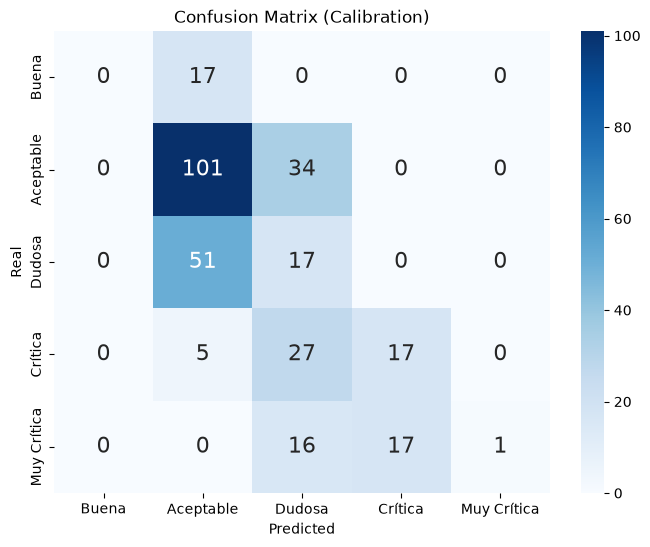

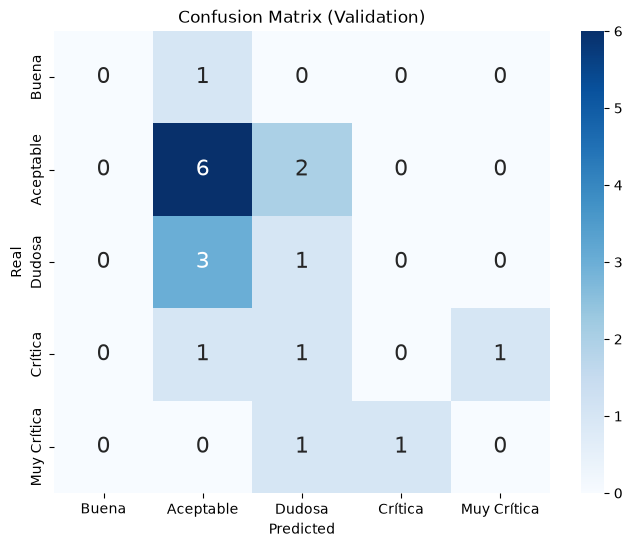

Classification report - calibration:

              precision    recall  f1-score   support

       Buena       0.00      0.00      0.00        17
   Aceptable       0.58      0.75      0.65       135
      Dudosa       0.18      0.25      0.21        68
     Crítica       0.50      0.35      0.41        49
 Muy Crítica       1.00      0.03      0.06        34

    accuracy                           0.45       303
   macro avg       0.45      0.27      0.27       303
weighted avg       0.49      0.45      0.41       303

Classification report - validation:

              precision    recall  f1-score   support

       Buena       0.00      0.00      0.00         1
   Aceptable       0.55      0.75      0.63         8
      Dudosa       0.20      0.25      0.22         4
     Crítica       0.00      0.00      0.00         3
 Muy Crítica       0.00      0.00      0.00         2

    accuracy                           0.39        18
   macro avg       0.15      0.20      0.17        18
we

In [6]:
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

bmwp_classes = {
    'Buena': (101, 120),
    'Aceptable': (61, 100),
    'Dudosa': (36, 60),
    'Crítica': (16, 35),
    'Muy Crítica': (0, 15),
}

def classify_bmwp(value):
    for label, (lower, upper) in bmwp_classes.items():
        if lower <= value <= upper:
            return label
    return None

X = df[['Dureza']]
y = df['BMWP']
loo = LeaveOneOut()

y_true_val, y_pred_val = [], []
y_true_cal, y_pred_cal = [], []

for train_index, val_index in loo.split(X):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]

    X_train_const = sm.add_constant(X_train, has_constant='add')
    X_val_const = sm.add_constant(X_val, has_constant='add')

    results = sm.GLM(y_train, X_train_const, family=sm.families.NegativeBinomial()).fit()

    y_pred_cal += results.predict(X_train_const).tolist()
    y_true_cal += y_train.tolist()
    y_pred_val.append(results.predict(X_val_const).iloc[0])
    y_true_val.append(y_val.iloc[0])

# Map continuous predictions to BMWP classes
y_pred_val_class = [classify_bmwp(v) for v in y_pred_val]
y_true_val_class = [classify_bmwp(v) for v in y_true_val]
y_pred_cal_class = [classify_bmwp(v) for v in y_pred_cal]
y_true_cal_class = [classify_bmwp(v) for v in y_true_cal]

# Drop any None (out-of-range) entries
def drop_none(true_list, pred_list):
    idx = [i for i, (t, p) in enumerate(zip(true_list, pred_list)) if t is not None and p is not None]
    return [true_list[i] for i in idx], [pred_list[i] for i in idx]

y_true_cal_class, y_pred_cal_class = drop_none(y_true_cal_class, y_pred_cal_class)
y_true_val_class, y_pred_val_class = drop_none(y_true_val_class, y_pred_val_class)

labels = list(bmwp_classes.keys())
cal_matrix = confusion_matrix(y_true_cal_class, y_pred_cal_class, labels=labels)
val_matrix = confusion_matrix(y_true_val_class, y_pred_val_class, labels=labels)

def plot_confusion_matrix(cm, labels, title):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 16},
                xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('Real')
    plt.title(title)
    plt.show()

plot_confusion_matrix(cal_matrix, labels, 'Confusion Matrix (Calibration)')
plot_confusion_matrix(val_matrix, labels, 'Confusion Matrix (Validation)')

print("Classification report - calibration:\n")
print(classification_report(y_true_cal_class, y_pred_cal_class, labels=labels, target_names=labels))
print("Classification report - validation:\n")
print(classification_report(y_true_val_class, y_pred_val_class, labels=labels, target_names=labels))

## Visualisation

Fitted negative binomial curve of BMWP as a function of total hardness.

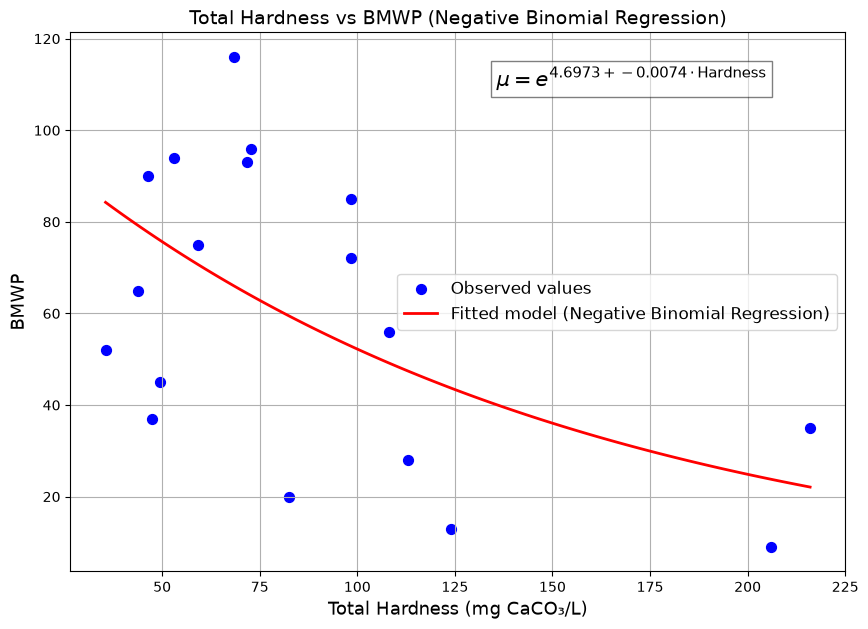

In [7]:
# Refit on the full sample for the fitted-curve plot
X_full = sm.add_constant(df[['Dureza']], has_constant='add')
results = sm.GLM(df['BMWP'], X_full, family=sm.families.NegativeBinomial()).fit()

intercept = results.params['const']
coef_hardness = results.params['Dureza']

hardness_continuous = np.linspace(df['Dureza'].min(), df['Dureza'].max(), 100)
X_pred = sm.add_constant(pd.DataFrame({'Dureza': hardness_continuous}), has_constant='add')
bmwp_predicted = results.predict(X_pred)

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(df['Dureza'], df['BMWP'], label='Observed values', color='blue', s=50)
ax.plot(hardness_continuous, bmwp_predicted, color='red', linewidth=2,
        label='Fitted model (Negative Binomial Regression)')
ax.set_xlabel('Total Hardness (mg CaCO₃/L)', fontsize=13)
ax.set_ylabel('BMWP', fontsize=13)
ax.set_title('Total Hardness vs BMWP (Negative Binomial Regression)', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True)
equation_text = rf"$\mu = e^{{{intercept:.4f} + {coef_hardness:.4f} \cdot \mathrm{{Hardness}}}}$"
ax.text(0.55, 0.9, equation_text, transform=ax.transAxes, fontsize=15, color='black',
        bbox=dict(facecolor='white', edgecolor='black', alpha=0.5))
fig.savefig("../../figures/negative_binomial_BMWP.png", dpi=300, bbox_inches='tight')
plt.show()

## Cohen's Kappa and metric export (for the master table)

In [8]:
# Cohen's Kappa for the BMWP LOOCV (class-level) and export for the master table.
from sklearn.metrics import cohen_kappa_score, precision_recall_fscore_support, accuracy_score

# y_true_val_class / y_pred_val_class were produced by the LOOCV cell above
kappa_bmwp = cohen_kappa_score(y_true_val_class, y_pred_val_class)
present = [c for c in labels if c in y_true_val_class]
prec, rec, f1m, _ = precision_recall_fscore_support(
    y_true_val_class, y_pred_val_class, labels=present, average='macro', zero_division=0)
acc_bmwp = accuracy_score(y_true_val_class, y_pred_val_class)
print(f"BMWP LOOCV (negative binomial): accuracy={acc_bmwp:.3f}  Cohen's Kappa={kappa_bmwp:.3f}")

import pandas as pd
pd.DataFrame([{'target': 'BMWP', 'technique': 'Negative binomial reg.', 'validation': 'LOOCV',
               'n': 18, 'precision': round(prec, 3), 'recall': round(rec, 3), 'f1': round(f1m, 3),
               'accuracy': round(acc_bmwp, 3), 'kappa': round(kappa_bmwp, 3)}]
             ).to_csv("../../outputs/metrics_nb.csv", index=False)
print("Saved outputs/metrics_nb.csv")

BMWP LOOCV (negative binomial): accuracy=0.389  Cohen's Kappa=0.062
Saved outputs/metrics_nb.csv
